In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

from tensorflow.keras import Sequential
from tensorflow.keras.datasets import mnist as mnist_keras
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D

import joblib

### Datan 

MNIST är et set med handskriva siffror. Det finns **70000** datapunkter i träningsdatan där **10000** är avsedda för test. Jag har valt att dela upp datan i ***50000*** för träning, ***10000*** för validering och **10000** för test. Test och valideringsetsen används i kombination i det fall jag använder cross_validate.



In [3]:
mnist = fetch_openml(name='mnist_784', cache=True, as_frame=False)

X = mnist["data"]
y = mnist["target"].astype(np.uint8)
                                   
print(X.shape)
print(y.shape)



(70000, 784)
(70000,)


På bilden visas en datapunkt med label:  5


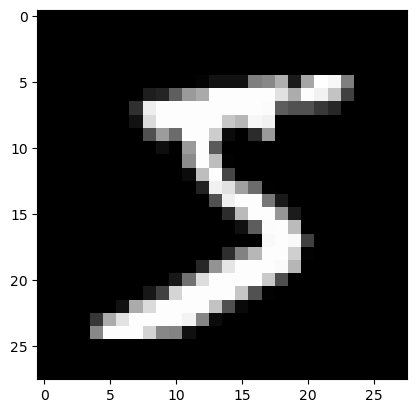

In [4]:

some_digit = X[0]
some_digit_image = some_digit.reshape(28,28)
plt.imshow(some_digit_image, cmap="gray")
print("På bilden visas en datapunkt med label: ", y[0])

In [4]:
X[0][:200] # visar de första 200 pixlarna i den första datapunkten

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

Det är ett rimligt antagande att fördeleningen mellan siffrorna i MNIST jämn.
För att bekräfta detta kan vi titta på fördelningen av klasser:


<Axes: >

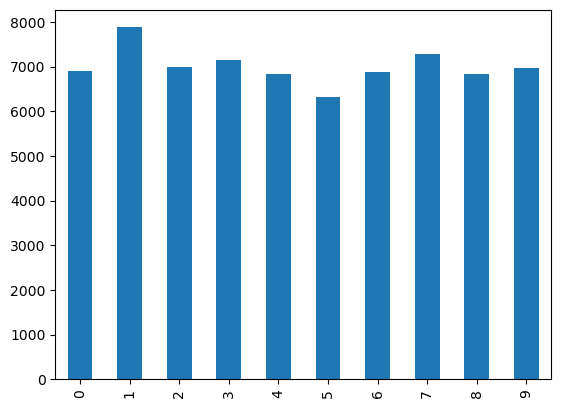

In [5]:
print("Det är ett rimligt antagande att fördeleningen mellan siffrorna i MNIST jämn.")
print("För att bekräfta detta kan vi titta på fördelningen av klasser:")

val_counts = pd.Series(y).value_counts()
val_counts.sort_index(inplace=True)
val_counts.plot(kind='bar')

Stapeldiagrammet ovan visar att datasetet är balanserat mellan klasserna. 

Varje bild är 28x28px stor. Siffran sparas som en array av pixlar där varje pixel är en feature. Varje bild har därför ***784 features*** + en label som håller informationen om vilken siffra bilden representerar (y). Vi kan även se att siffran är i gråskala och att färgerna är inverterade. Bakgrunden är alltså svart (represeneras av värdet 0 i matrisen) medan själva siffran är grå eller vit (> 1 <= 255). 

In [5]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, 
                                                            test_size=10000, 
                                                            random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, 
                                                  test_size=10000, 
                                                  random_state=42)

#skala datan
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train, y_train)

X_train_val = scaler.transform(X_train_val)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

### Val av modell
En av det första frågorna jag ställde mig var om MNIST var linjärt separerbart och om jag kunde testa det. Eftersom datasetet är högdimensionellt så är det inte enkelt att se. Jag valde därför att köra **Logistisk Regression** för att ha en bas att jämföra de andra modellernas prestanda mot. Tidigt i processen så tänkte jag att jag kunde lägga till en polynomterm för att se hur det påverkade resultatet. Det var lärorikt. Det jag framförallt lärde mig var att det var en dålig ide. MNIST är så högdimensionellt att det ledde till feature explosion, vilken i sin tur gjorde modellen omöjlig att köra på min dator. Den fick slut på minne. Man hade kanske kunnat lösa det med ett mindre subset i kombination med dimensionsreducering, men istället så valde jag att tuna kernel parametern på min SVC modell.

De primära modellerna jag valde att utvärdera var **SVM**, **RandomForest** och **ExtraTrees**. 
Slutligen ville jag även utvärdera en DL modell för att se hur den presetrar mot de traditionella ML modellerna. Jag valde **CNN** för detta. 

### Val av utvärderingsmått

Eftersom MNIST är ett klassifieringsproblem så behöver man förhålla sig till vilket utvärderingsmått som är rimligt för datan. I fallet MNIST så har vi sett att det är jämnt fördelat mellan klasserna. Vi kan också anta att en siffra inte är viktigare än en annan. Med det i åtanke så har jag valt **accuracy** under modellutvärderingen.

För de modeller jag utvärderade mot testdatan så har jag även använt mig av mig av **Confusion Matrix** för att få en bild av hur modellen presterar på olika klasser, samt **classification resport**.     

In [ ]:
"""
Logistisk regression. 
Korsvalidering av hyperparemetern C (regulariseringsstyrka).

"""

log_reg = LogisticRegressionCV(
    Cs=[0.001, 0.01, 0.1, 1],
    max_iter=500, 
    random_state=42)

log_reg.fit(X_train, y_train)

log_reg_val_pred = log_reg.predict(X_val)

log_reg_accuracy = accuracy_score(y_val, log_reg_val_pred)
print("Logistisk regression accuracy score:", log_reg_accuracy)
print("Optimalt värde på C (regulariseringsstyrka)för varje klass: ", log_reg.C_)

Logistisk regression accuracy score: 0.9221
Optimalt värde på C (regulariseringsstyrka)för varje klass:  [0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]


### SVM

För klassiiceringsproblem har scikit learn två SVM modeller: SVC och LinearSVC. Enligt dokumentationen är LinearSVC mer flexibel för bland annat val av penalties och skall skala bättre för större datasets. Dock använder den alltid linear som kernel. Eftersom vi inte vet om vårat dataset är linjärt så har jag använt mig av **SVC**.

SVM är en modell som rekommenderas för små eller mellanstora datasets. Enligt dokumentationen kan SVC vara opålitligt på datasets med mer än tiotusentals datapunker. Vårt dataset borde inte vara för stort. 
SVM är även långsamt att träna. Jag har därför valt att tuna hyperparametrarna på ett subset av 10000 poster och tre delar i korsvalideringen. Jag har valt att tuna variablerna **C** och **kernel**.

Jag har även tunat gamma variablen för den bästa kerneln (rbf) innan jag gjort en cross_validation för att utvärdera modellen.

In [8]:

X_train_subset = X_train[:10000]
y_train_subset = y_train[:10000]

In [37]:
svc_grid = GridSearchCV(SVC(), param_grid={
    'C': [0.001, 0.01, 0.1, 1], 
    'kernel' : ['rbf', 'linear', 'poly']}, cv=3, verbose=2)

svc_grid.fit(X_train_subset, y_train_subset)
svc_grid_val_pred = svc_grid.predict(X_val)

svc_grid_accuracy = accuracy_score(y_val, svc_grid_val_pred)
print("SVC accuracy score:", svc_grid_accuracy)
print("Bästa parametrar för SVC:", svc_grid.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END ................................C=0.001, kernel=rbf; total time=  28.5s
[CV] END ................................C=0.001, kernel=rbf; total time=  28.8s
[CV] END ................................C=0.001, kernel=rbf; total time=  27.6s
[CV] END .............................C=0.001, kernel=linear; total time=   5.9s
[CV] END .............................C=0.001, kernel=linear; total time=   6.0s
[CV] END .............................C=0.001, kernel=linear; total time=   5.8s
[CV] END ...............................C=0.001, kernel=poly; total time=  23.7s
[CV] END ...............................C=0.001, kernel=poly; total time=  23.0s
[CV] END ...............................C=0.001, kernel=poly; total time=  22.6s
[CV] END .................................C=0.01, kernel=rbf; total time=  26.5s
[CV] END .................................C=0.01, kernel=rbf; total time=  27.4s
[CV] END .................................C=0.01

In [ ]:
#fit the whole set with the best parameters
svc1 = SVC(C=1,
    kernel="rbf" 
)

svc_gs_rbf=GridSearchCV(svc1, param_grid={
    'gamma': [0.001, 0.01, 0.1, 1]}, cv=5, verbose=1)
svc_gs_rbf.fit(X_train_subset, y_train_subset)

svc_gs_rbf_val = svc_gs_rbf.predict(X_val)
svc_gs_rbf_accuracy = accuracy_score(y_val, svc_gs_rbf_val)
print("SVC accuracy score:", svc_gs_rbf_accuracy)
print("Bästa gamma för SVC med RBF-kernel:", svc_gs_rbf.best_params_['gamma'])

Fitting 5 folds for each of 4 candidates, totalling 20 fits
SVC accuracy score: 0.9345
Bästa gamma för SVC med RBF-kernel: 0.001


## SVC och komplexitet

När jag först utvärderade SVC modellerna gjorde jag en gridsearch på hela datasetet. Jag gav upp när modellen hade tuggat på i 300 minuter, och skalade ner till ett mindre dataset. Intressant nog verkade inte tiden gridsearch tog skala linjärt med storleken på datasetet. Efter lite googlande fick jag fram att komplexiteten för SVM är ungefär *O(n_samples^2 * n_features)* (O här är big O notation, vilken var en kunskap som vaknade i mig likt en sleeper agent när jag läste det). 

Det var hjälpsamt att sätta verbositeten till 2 när jag körde långsamma funktioner som gridsearch eftersom det get en indikation på hur lång tid varje iteration tar. Det hjälpte mig också att förstå gridsearch bättre när man ser vad den faktiskt gör. Jag har tagit bort det på de flesta ställena för att göra filen mer läsbar, men har kvar det i fösrta instanden av grid_search för SVC. 

In [ ]:
""" Fit the whole set with the best parameters and cross validate """

svc_cv = SVC(C=1, 
    kernel="rbf",
    gamma=0.001)


cross_val_scores = cross_validate(
    svc_cv, 
    X_train_val, 
    y_train_val, 
    cv=5, 
    return_train_score=True, 
    scoring='accuracy', 
    verbose=2)

print(cross_val_scores['test_score'])
print("SVC accuracy score mean:", cross_val_scores['test_score'].mean())

[CV] END .................................................... total time= 6.5min
[CV] END .................................................... total time= 6.3min
[CV] END .................................................... total time= 6.2min
[CV] END .................................................... total time= 4.8min
[CV] END .................................................... total time= 4.8min
[0.961      0.96283333 0.96066667 0.96325    0.96091667]
SVC accuracy score mean: 0.9617333333333333


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed: 61.5min finished


In [12]:
print(f"Mean fit time: {cross_val_scores['fit_time'].mean():.0f} seconds")
print(f"Mean score time: {cross_val_scores['score_time'].mean():.0f} seconds")

Mean fit time: 248 seconds
Mean score time: 97 seconds


### Decision Trees

För decision tree så har jag valt att fokusera på ensable modellerna Random Forest och Extra Trees istället för ett enskilt träd. Jag hade initialt med ett enskilt träd i undersökningen. Accuracy var då avsevärt lägre än t.ex Logistisk Regression. Jag tänkte först att jag kunde tuna hyerparametrar för ett träd och sedan använda dessa värden på ensamblemetoderna. Detta går att göra men jag kom till slutsatsen att det var lite onödigt. Ett träd är väldigt känsligt för overfitting medan både RandomForest och i synnerhet ExtraTrees är naturligt resistenta mot overfitting. Dock kan man kankse vilja sätta trädparametrarna till lägre värden för att få ett mindre träd. Min erfarenhet av mina tunade träd är att de växtre sig väldigt stora. 

In [ ]:
"""
Grid search för Random Forest to find best parameters. 
I initially had a larger value for n_estimators but the accuracy gain is small and the cost in speed and size is large. 
    
"""

rf = RandomForestClassifier(random_state=42,
                            max_features='sqrt')

rf_grid_search = GridSearchCV(rf, param_grid={
    'n_estimators': [100, 200],
    'max_depth': [10, 30, 100, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]}) #verbose=2) - tar ca 20-60 minuter att köra

rf_grid_search.fit(X_train_subset, y_train_subset)

rf_val_pred = rf_grid_search.predict(X_val)
rf_val_accuracy = accuracy_score(y_val, rf_val_pred)

print("Random Forest accuracy score:", rf_val_accuracy)
print("Bästa parametrar för Random Forest:", rf_grid_search.best_params_)

Random Forest accuracy score: 0.9499
Bästa parametrar för Random Forest: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
"""
Fit the whole set with the best parameters and cross validate.

"""

rf2 = RandomForestClassifier(random_state=42,
                            max_features='sqrt',
                            max_depth = 30,
                            min_samples_split=2,
                            min_samples_leaf=1,
                            n_estimators=200)

rf_cv_scores = cross_validate(
    rf2, 
    X_train_val, 
    y_train_val, 
    cv=5,
    return_train_score=True,
    scoring='accuracy') # ,verbose=2) - tar ca 10 minnuter att köra

print(rf_cv_scores['test_score'])
print(f"Random Forest accuracy score mean: {rf_cv_scores['test_score'].mean():.4f}")

[0.96691667 0.96941667 0.97058333 0.96925    0.968     ]
Random Forest accuracy score mean: 0.9688


In [15]:
print(f"Mean fit time: {rf_cv_scores['fit_time'].mean():.0f} seconds")
print(f"Mean score time: {rf_cv_scores['score_time'].mean():.0f} seconds")

Mean fit time: 92 seconds
Mean score time: 2 seconds


In [ ]:
"""
Grid search för Extra Trees to find best parameters.

"""

et1 = ExtraTreesClassifier(random_state=42, n_jobs=5)

et_gs = GridSearchCV(et1, 
                     param_grid={
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_depth': [10, 30, 100, None],
    'n_estimators': [100, 200]}) #,verbose=2) - tar ca 10 minuter att köra

et_gs.fit(X_train_subset, y_train_subset)
et_gs_val_pred = et_gs.predict(X_val)
et_gs_val_accuracy = accuracy_score(y_val, et_gs_val_pred)

print("Extra Trees accuracy score:", et_gs_val_accuracy)
print("Bästa parametrar för Extra Trees:", et_gs.best_params_) 

Extra Trees accuracy score: 0.9511
Bästa parametrar för Extra Trees: {'max_depth': 100, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Bästa parametrar vid körning av koden ovan:
{'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}


In [ ]:
"""
Fit the whole set with the best parameters and cross validate.

"""

et = ExtraTreesClassifier(
    n_estimators=200,
    n_jobs=4,
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=1)
    
#et = ExtraTreesClassifier(n_estimators=400, random_state=8, n_jobs=4)
et_cross_val_scores = cross_validate(
    et, 
    X_train_val, 
    y_train_val, 
    cv=5, 
    return_train_score=True, 
    scoring='accuracy', 
    verbose=2)

print(et_cross_val_scores['test_score'])
print(f"Extra Trees accuracy score mean: {et_cross_val_scores['test_score'].mean():.4f}")

[CV] END .................................................... total time=  15.4s
[CV] END .................................................... total time=  15.6s
[CV] END .................................................... total time=  14.8s
[CV] END .................................................... total time=  13.9s
[CV] END .................................................... total time=  13.7s
[0.97       0.97225    0.97425    0.97141667 0.9705    ]
Extra Trees accuracy score mean: 0.9717


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  1.3min finished


In [18]:
print(f"Mean fit time: {et_cross_val_scores['fit_time'].mean():.0f} seconds")
print(f"Mean score time: {et_cross_val_scores['score_time'].mean():.0f} seconds")

Mean fit time: 14 seconds
Mean score time: 0 seconds


### Utvärdering av klassiska modeller

Som bas att jämföra värdena med så var accuracy för LogisticalRegressionCV 0.9221. Här är siffrorna för de andra klassiska modellerna efter en 5-fold cross validering med tränings- och valideringsdata:

| Modell | Mean cccuracy | Mean fit time (s) | Mean score time (s) |
| ----------- | ----------- | ----------- | ----------- |
| SVC | 0.9617 | 243 | 88 |
| Random Forest | 0.9688 | 92 | 2 |
| Extra Trees | 0.9717 | 14 | >1 |

Extra Trees presterar bäst.

### CNN

Jag ville även utvärdera en DL modell och valde att använda mig av CNN.

Tensorflow/keras har en version av MNIST som är i rätt format, så för enkelhetens skull läse jag in den. Jag har även skrivit ut en bild.  

Min CNN modell har 4 convolution layers. Jag har inte tunat hyperparametrarna. 

X_train_cnn shape: (60000, 28, 28)
y_train_cnn shape: (60000,)


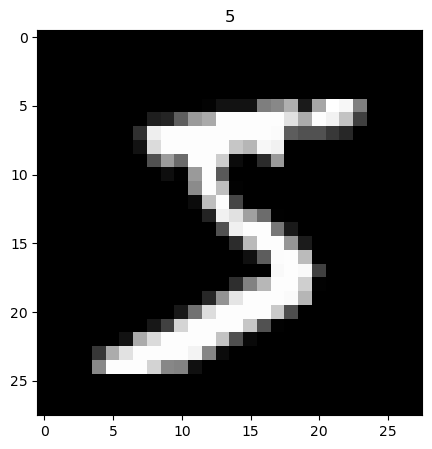

In [19]:
#Load MNIST from keras

(X_train_cnn, y_train_cnn), (X_test_cnn, y_test_cnn)  = mnist_keras.load_data()

print("X_train_cnn shape:", X_train_cnn.shape)
print("y_train_cnn shape:", y_train_cnn.shape)

# Normalize data
X_train_cnn = X_train_cnn / 255.0
X_test_cnn = X_test_cnn / 255.0

# Show the first image
plt.figure(figsize=(5,5))
plt.imshow(X_train_cnn[0], cmap='gray')
plt.title(y_train_cnn[0])
plt.show()


In [20]:
cnn = Sequential()
cnn.add(Input(shape=(28, 28, 1)))
cnn.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'))
cnn.add(MaxPooling2D(pool_size=(2, 2)))
cnn.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
cnn.add(MaxPooling2D(pool_size=(2, 2)))
cnn.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'))
cnn.add(MaxPooling2D(pool_size=(2, 2)))
cnn.add(Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'))
cnn.add(MaxPooling2D(pool_size=(2, 2)))
cnn.add(Flatten())
cnn.add(Dropout(0.5))
cnn.add(Dense(128, activation='relu'))
cnn.add(Dense(10, activation='softmax'))

cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [21]:
history = cnn.fit(
    X_train_cnn, 
    y_train_cnn, 
    epochs=10, 
    batch_size=64, 
    verbose=2, 
    validation_split=0.1)

Epoch 1/10
844/844 - 15s - 17ms/step - accuracy: 0.9214 - loss: 0.2454 - val_accuracy: 0.9845 - val_loss: 0.0521
Epoch 2/10
844/844 - 13s - 15ms/step - accuracy: 0.9800 - loss: 0.0655 - val_accuracy: 0.9870 - val_loss: 0.0418
Epoch 3/10
844/844 - 12s - 15ms/step - accuracy: 0.9858 - loss: 0.0486 - val_accuracy: 0.9917 - val_loss: 0.0292
Epoch 4/10
844/844 - 13s - 15ms/step - accuracy: 0.9890 - loss: 0.0379 - val_accuracy: 0.9928 - val_loss: 0.0291
Epoch 5/10
844/844 - 13s - 15ms/step - accuracy: 0.9910 - loss: 0.0305 - val_accuracy: 0.9933 - val_loss: 0.0258
Epoch 6/10
844/844 - 13s - 15ms/step - accuracy: 0.9918 - loss: 0.0264 - val_accuracy: 0.9928 - val_loss: 0.0301
Epoch 7/10
844/844 - 13s - 15ms/step - accuracy: 0.9928 - loss: 0.0234 - val_accuracy: 0.9898 - val_loss: 0.0393
Epoch 8/10
844/844 - 12s - 15ms/step - accuracy: 0.9939 - loss: 0.0194 - val_accuracy: 0.9912 - val_loss: 0.0351
Epoch 9/10
844/844 - 13s - 16ms/step - accuracy: 0.9938 - loss: 0.0191 - val_accuracy: 0.9937 - 

### Utvärdering av modeller

Jag har valde att gå vidare med Extra Trees och CNN. Nästa steg är att utvärdera dem mot testdatan. I utvärderingan har jag använt mig av Confusion Matrix och Classification Report. Generellt har Extra Trees en accuracy på ungefär 97% mot testdatan och CNN runt 99%. Den är möjligen något lägre än på träning/validering setet, men inte markant. Vi kan se att den har mer problem med vissa siffror, till exempel nior.

In [ ]:
""" Testa CNN mot test data """

cnn_test_pred = cnn.predict(X_test_cnn)
cnn_test_pred_classes = np.argmax(cnn_test_pred, axis=1)
accuracy_cnn_test = accuracy_score(y_test_cnn, cnn_test_pred_classes)

cnn_report = classification_report(y_test_cnn, cnn_test_pred_classes)
cnn_matrix = confusion_matrix(y_test_cnn, cnn_test_pred_classes)
print("Results for CNN on test data:")
print()
print("Accuracy: ", accuracy_cnn_test)
print()
print("Classification Report: ")
print(cnn_report)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Results for CNN on test data:

Accuracy:  0.993

Classification Report: 
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



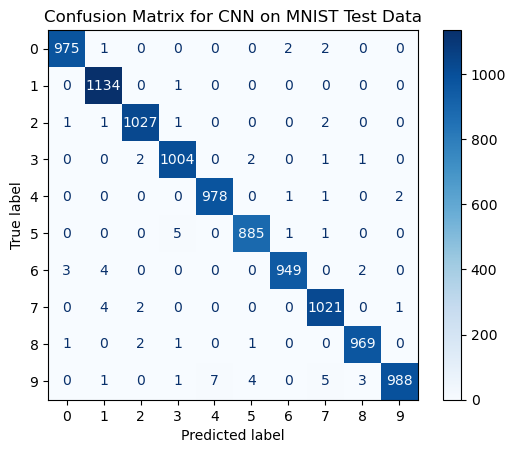

In [23]:
cnn_cm_display = ConfusionMatrixDisplay(confusion_matrix=cnn_matrix, display_labels=np.arange(10))
cnn_cm_display.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix for CNN on MNIST Test Data")
plt.show()

In [6]:
""" Träna Extra Trees på hela träningsdatan med de bästa parametrarna och testa mot test datan. """

et_train = ExtraTreesClassifier(
    n_estimators=200,
    n_jobs=4,
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=1)

et_train.fit(X_train_val, y_train_val)


,n_estimators,200
,criterion,'gini'
,max_depth,30
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [7]:
et_train_pred = et_train.predict(X_test)
et_train_accuracy = accuracy_score(y_test, et_train_pred)

et_report = classification_report(y_test, et_train_pred)
et_matrix = confusion_matrix(y_test, et_train_pred)

print("Results for Extra Trees on test data:")
print()
print("Accuracy: ", et_train_accuracy)
print()
print("Classification Report: ")
print(et_report)

Results for Extra Trees on test data:

Accuracy:  0.9701

Classification Report: 
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       983
           1       0.99      0.99      0.99      1152
           2       0.95      0.97      0.96       967
           3       0.96      0.96      0.96      1034
           4       0.97      0.97      0.97       906
           5       0.98      0.97      0.97       937
           6       0.98      0.98      0.98       961
           7       0.97      0.97      0.97      1055
           8       0.96      0.95      0.96       969
           9       0.96      0.95      0.96      1036

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



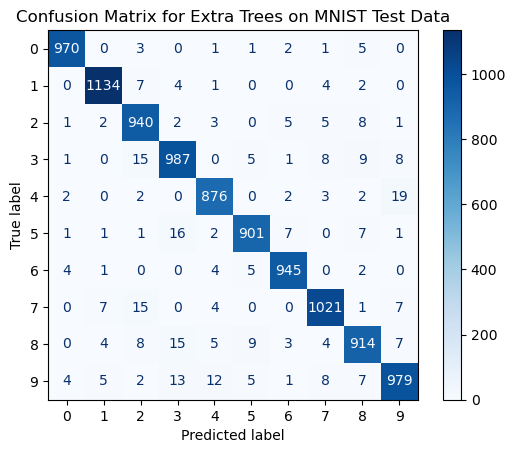

In [26]:
et_cm_display = ConfusionMatrixDisplay(confusion_matrix=et_matrix, display_labels=np.arange(10))
et_cm_display.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix for Extra Trees on MNIST Test Data")
plt.show()

### Produktionssättning av modell

Jag har valt att spara både Extra Trees och CNN för att testa dem med min Streamlit app.  

In [ ]:
""" 
Träna Extra Trees på det fullständiga datasetet. 
Notera att jag har en pipeline med StandardScaler. 
Det är för att predict metoden skall skala ny data så att den matchar träningsdatan. 
"""

et_full = ExtraTreesClassifier(
    n_estimators=200,
    n_jobs=4,
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=1)


extra_trees_pipeline = make_pipeline(StandardScaler(), et_full)

extra_trees_pipeline.fit(X, y)

joblib.dump(extra_trees_pipeline, "../models/extra_trees_mnist_pipeline_v3.pkl") 

['../models/extra_trees_mnist_pipeline_v3.pkl']

In [ ]:
"""
 För CNN har har bara sparat modellen som den är, d.v.s utan att träna den på testdatan.
"""
joblib.dump(cnn, '../models/cnn_mnist_model.pkl')

['../models/cnn_mnist_model.pkl']

### Test med appen

GIT: https://github.com/heleneandersson-se/mnist-app-cloud

Streamlit Cloud: https://mnist-app-cloud-f8zhxvykaufsafhtnpdb3q.streamlit.app/

Jag byggde en streamlit app för att testa mina två modeller. Som input har jag använt ett HTML5 canvas element som stödjer både muspekare och touch input.

Jag har testat både med ExtraTrees och CNN i appen. ExtraTrees modellen är så stor att jag enbart jobbat med den lokalt. Versionen på GIT och Streamlit Cloud läser nu in CNN modellen från dropbox. Det var en nödlösning efter att ExtraTrees modellen kvickt åt upp min GIT LFS quota på GitHub. 

Anekdotiskt (efter att ha gjort många test med appen men inte trackat statistik) så är accuracy på den nya datan är sämre än på testsetet. Sannolikt beror detta åtminstone delvis på olikheter i input datan och datasetet som modellen tränats på. 

Jag fick båda modellerna att prestera bättre genom att centrera bilderna och skala siffrorna till samma storlek. Båda modellerna var känsliga för siffror som t.ex var uppe i ett hörn. Med justeringarna presterar CNN oftast bra så länge siffrorna inte är vinklade eller har oväntade former (ihoptryckta t.ex), men jag upplever att ExtraTrees fortfarande har svårt med en del siffror. 


## Utvärderingsfrågor

1. Har något varit utmanande i kursen/kunskapskontrollerna? Om ja, hur har 
du hanterat det?

Nej inget speciellt.

2. Vilket betyg anser du att du ska ha och varför? 

Jag hade tänkt satsa på G men när jag väl kom igång så byggde jag en streamlit app för att utvärdera nya prediktioner, så jag ligger nog på en VG nivå ändå. Jag upplever att jag har bra förståelse för de flesta sakerna som har ingått i kursen.

3. Något du vill lyfta fram till Terese?

Jag kände mig lite lost när det kom till att utvärdera modellen på ny data. Problemet uppstod delvis för att MNIST är just bilder, men det känns lite som att mycket handlar om träningen och inte så mycket om vad man gör sedan med den tränade datan. Det är dock en mycket marginell sak och överlag har jag inte saknat något. 

Toppen med en längre uppgift som kunskapskontroll, mycket föll på plats där. :)